In [97]:
from __future__ import absolute_import, division, print_function, unicode_literals

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

from IPython.display import clear_output
from six.moves import urllib

import tensorflow.compat.v2.feature_column as fc
import tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

# Importing , Splicing, and Scaling the dataset

In [98]:
# Importing
df_electric = pd.read_csv("/home/whitelister/PycharmProjects/Learning AI/ML/Datasets/individual+household+electric+power+consumption/household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False)

df_electric.columns = [c.upper() for c in df_electric.columns]

# Encoding
numeric_cols = [
    "GLOBAL_ACTIVE_POWER",
    "GLOBAL_REACTIVE_POWER",
    "VOLTAGE",
    "GLOBAL_INTENSITY",
    "SUB_METERING_1",
    "SUB_METERING_2",
    "SUB_METERING_3"
]

df_electric[numeric_cols] = df_electric[numeric_cols].astype(float)

df_electric["DATETIME"] = pd.to_datetime(
    df_electric["DATE"] + " " + df_electric["TIME"],
    format="%d/%m/%Y %H:%M:%S"
)

df_electric["YEAR"] = df_electric["DATETIME"].dt.year
df_electric["MONTH"] = df_electric["DATETIME"].dt.month
df_electric["DAY"] = df_electric["DATETIME"].dt.day
df_electric["HOUR"] = df_electric["DATETIME"].dt.hour
df_electric["MINUTE"] = df_electric["DATETIME"].dt.minute
df_electric["DAY_OF_WEEK"] = df_electric["DATETIME"].dt.dayofweek
df_electric["WEEKEND"] = (df_electric["DAY_OF_WEEK"] >= 5).astype(int)

df_electric.drop(columns=["DATE", "TIME", "DATETIME"], inplace=True)

df_electric[:5]
df_electric = df_electric.interpolate(method="linear")
df_electric = df_electric.dropna()

# Splicing
df = df_electric.sample(frac=1, random_state=42).reset_index(drop=True)

train = df.iloc[:int(0.6 * len(df))]
valid = df.iloc[int(0.6 * len(df)):int(0.8 * len(df))]
test = df.iloc[int(0.8 * len(df)):]

In [99]:
def check_scaled(name, X):
    print(f"\n{name}")
    print(f"Shape: {X.shape}")
    print(f"Mean: {X.mean():.6f}")
    print(f"Std : {X.std():.6f}")
    print(f"Min : {X.min():.6f}")
    print(f"Max : {X.max():.6f}")

check_scaled("Training", x_train)
check_scaled("Validation", x_valid)
check_scaled("Test", x_test)


Training
Shape: (1245155, 13)
Mean: nan
Std : nan
Min : nan
Max : nan

Validation
Shape: (415052, 13)
Mean: nan
Std : nan
Min : nan
Max : nan

Test
Shape: (415052, 13)
Mean: nan
Std : nan
Min : nan
Max : nan


In [100]:
def scale_dataset(dataframe, scaler=None, fit_scaler=False):

    y = dataframe["GLOBAL_ACTIVE_POWER"]

    X = dataframe.drop(columns=["GLOBAL_ACTIVE_POWER"])

    if fit_scaler:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    else:
        X = scaler.transform(X)

    return X, y.to_numpy(), scaler

In [101]:
x_train, y_train, scaler = scale_dataset(
    train,
    fit_scaler=True
)

x_valid, y_valid, _ = scale_dataset(
    valid,
    scaler=scaler
)

x_test, y_test, _ = scale_dataset(
    test,
    scaler=scaler
)

In [102]:
def check_scaled(name, X):
    print(f"\n{name}")
    print(f"Shape: {X.shape}")
    print(f"Mean: {X.mean():.6f}")
    print(f"Std : {X.std():.6f}")
    print(f"Min : {X.min():.6f}")
    print(f"Max : {X.max():.6f}")

check_scaled("Training", x_train)
check_scaled("Validation", x_valid)
check_scaled("Test", x_test)


Training
Shape: (1245155, 13)
Mean: -0.000000
Std : 1.000000
Min : -5.353941
Max : 14.182493

Validation
Shape: (415052, 13)
Mean: 0.000318
Std : 0.999284
Min : -5.443473
Max : 14.019265

Test
Shape: (415052, 13)
Mean: -0.000302
Std : 0.998244
Min : -5.242797
Max : 14.019265


# MODEL

In [103]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble.HistGradientBoostingClassifier import regressor?

# Create model
lr_model = LinearRegression()

# Train
lr_model.fit(x_train, y_train)

# Predict
y_pred = lr_model.predict(x_test)

Object `regressor` not found.


In [104]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.0256
MSE  : 0.0016
RMSE : 0.0402
R²   : 0.9985


LINEAR REGRESSION RESULTS
MAE  : 0.0256
MSE  : 0.0016
RMSE : 0.0402
R²   : 0.9985


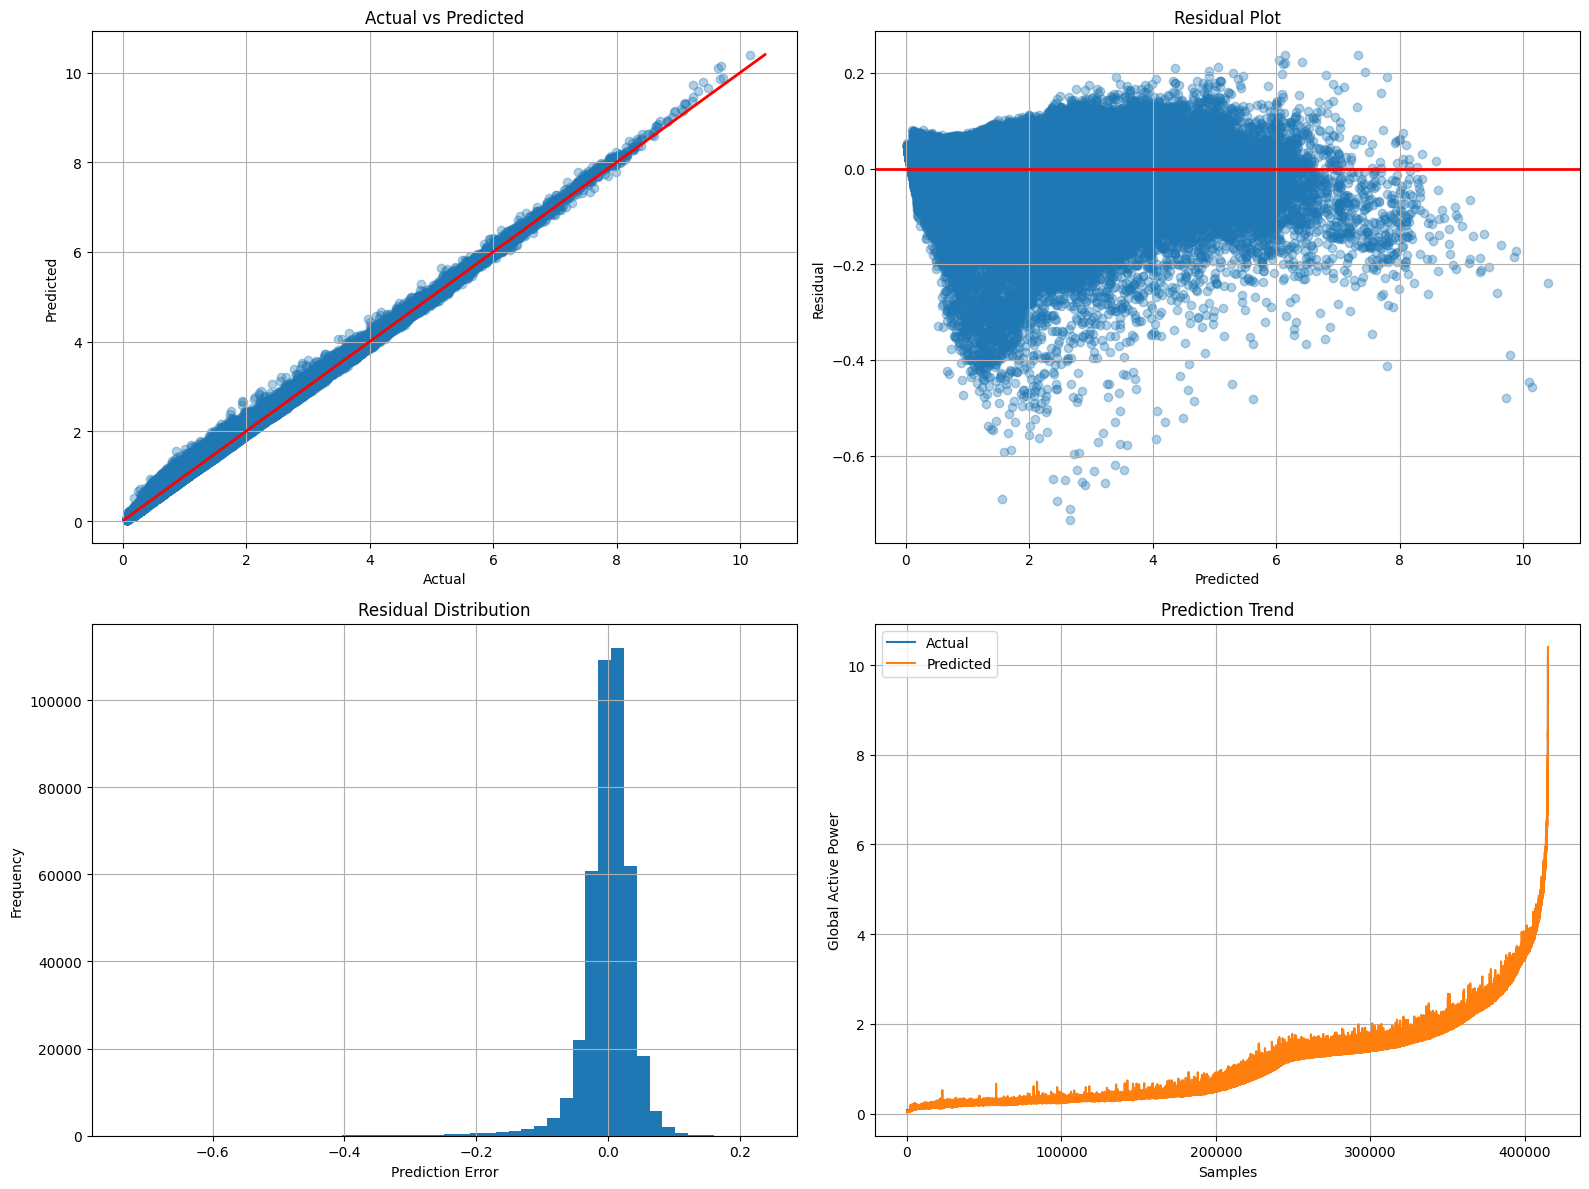


First 20 Predictions


,Actual,Predicted,Error,Absolute Error
0,1.40200,1.360507,0.041493,0.041493
1,0.29800,0.347917,-0.049917,0.049917
2,0.26400,0.295458,-0.031458,0.031458
3,3.65200,3.576605,0.075395,0.075395
4,0.24000,0.236839,0.003161,0.003161
5,0.53200,0.513308,0.018692,0.018692
6,0.24200,0.254888,-0.012888,0.012888
7,0.25200,0.294818,-0.042818,0.042818
8,0.20000,0.178981,0.021019,0.021019
9,0.49200,0.477119,0.014881,0.014881



Largest Errors


,Actual,Predicted,Error,Absolute Error
113368,1.936,2.670747,-0.734747,0.734747
132274,1.952,2.664449,-0.712449,0.712449
92586,1.762,2.457053,-0.695053,0.695053
365889,0.872,1.562616,-0.690616,0.690616
388075,2.242,2.903101,-0.661101,0.661101
133871,2.564,3.221801,-0.657801,0.657801
101999,2.204,2.858878,-0.654878,0.654878
42977,1.934,2.586216,-0.652216,0.652216
284653,1.744,2.392235,-0.648235,0.648235
148957,2.424,3.055767,-0.631767,0.631767



Top 15 Most Influential Features


,Feature,Coefficient
2,GLOBAL_INTENSITY,1.053058
0,GLOBAL_REACTIVE_POWER,-0.019851
5,SUB_METERING_3,0.018718
1,VOLTAGE,0.014490
9,HOUR,0.003094
4,SUB_METERING_2,-0.002318
3,SUB_METERING_1,-0.001630
6,YEAR,0.000616
8,DAY,0.000482
11,DAY_OF_WEEK,0.000448


In [105]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =====================================================
# Evaluation Metrics
# =====================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("LINEAR REGRESSION RESULTS")
print("=" * 50)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# =====================================================
# Residuals
# =====================================================

residuals = y_test - y_pred

# =====================================================
# Combined Visualization
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---------------------------------
# 1. Actual vs Predicted
# ---------------------------------

axes[0,0].scatter(y_test, y_pred, alpha=0.35)

mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())

axes[0,0].plot([mn, mx], [mn, mx], color="red", linewidth=2)

axes[0,0].set_title("Actual vs Predicted")
axes[0,0].set_xlabel("Actual")
axes[0,0].set_ylabel("Predicted")
axes[0,0].grid(True)

# ---------------------------------
# 2. Residual Plot
# ---------------------------------

axes[0,1].scatter(y_pred, residuals, alpha=0.35)

axes[0,1].axhline(0, color="red", linewidth=2)

axes[0,1].set_title("Residual Plot")
axes[0,1].set_xlabel("Predicted")
axes[0,1].set_ylabel("Residual")
axes[0,1].grid(True)

# ---------------------------------
# 3. Residual Distribution
# ---------------------------------

axes[1,0].hist(residuals, bins=50)

axes[1,0].set_title("Residual Distribution")
axes[1,0].set_xlabel("Prediction Error")
axes[1,0].set_ylabel("Frequency")
axes[1,0].grid(True)

# ---------------------------------
# 4. Actual vs Predicted Trend
# ---------------------------------

order = np.argsort(y_test)

axes[1,1].plot(y_test[order], label="Actual")
axes[1,1].plot(y_pred[order], label="Predicted")

axes[1,1].set_title("Prediction Trend")
axes[1,1].set_xlabel("Samples")
axes[1,1].set_ylabel("Global Active Power")
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

# =====================================================
# First 20 Predictions
# =====================================================

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Error": y_test - y_pred
})

comparison["Absolute Error"] = comparison["Error"].abs()

print("\nFirst 20 Predictions")
display(comparison.head(20))

print("\nLargest Errors")
display(
    comparison.sort_values(
        "Absolute Error",
        ascending=False
    ).head(20)
)

# =====================================================
# Feature Importance
# =====================================================

feature_importance = pd.DataFrame({
    "Feature": train.drop(columns=["GLOBAL_ACTIVE_POWER"]).columns,
    "Coefficient": lr_model.coef_
})

feature_importance["Absolute"] = feature_importance["Coefficient"].abs()

feature_importance = (
    feature_importance
    .sort_values("Absolute", ascending=False)
    .drop(columns="Absolute")
)

print("\nTop 15 Most Influential Features")
display(feature_importance.head(15))